# **Tutorial 1: Creating an audiogram with wav2aud**
An auditory spectrogram, also known as audiogram, is a biologically calibrated version of a regular spectrogram. It is obtained by simulating the transduction from air pressure changes into electrical signals performed by the cochlea. In this case study, we will demonstrate the function wav2aud which creates an audiogram tuned to the ferret cochlea by Yang, Wang and Shamma \[[1](#References), [2](#References)\] which can be used as a proxy for the human cochlea.

## **Step 1: Select a sound file**
We prepared a variety of test sounds from which you can select one using the below widget. The first few sounds come from house-hold objects (e.g. materials being rubbed together). There are also a few natural sounds (crickets, geese, etc.) and one speech example. All sounds have a sampling frequency of 16000Hz, which is the default for `wav2aud`.

In [ ]:
from neural_audio.examples.sounds.load import load_sound_file_paths
import soundfile as soundf
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, Audio

# Get list of sound files 
sound_files = load_sound_file_paths()
sound_file_names = [Path(file).name for file in sound_files]

# Create dropwdown widget to select and play sound file
dropdown = widgets.Dropdown(options=sound_file_names, description='Sound file:')
audio_player = widgets.Output()
sound_file_path = sound_files[1]

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global sound_file_path
        for file in sound_files:
            if Path(file).name == change['new']: sound_file_path = file
        audio_player.clear_output()
        with audio_player:
            display(Audio(str(sound_file_path), autoplay=False))

dropdown.observe(on_change)
dropdown.value = sound_file_names[3]  # Set default value to the first sound file
display(dropdown, audio_player)


Dropdown(description='Sound file:', index=3, options=('cardboard tapping.wav', 'cardboard whirling.wav', 'cric…

Output()

## **Step 2: Create a first audiogram**

We can now pass the selected sound to the wav2aud function. The first argument of `wav2aud` is `x`, the acoustic waveform (1-dimensional array). All other arguments are optional and we will use their default values for now. A detailed documentation can be found on [read-the-docs](https://neural-audio.readthedocs.io/en/latest/index.html).

In [ ]:
from neural_audio.wav2aud import wav2aud

# Compute an audiogram with default parameters.
waveform, sampling_rate = soundf.read(sound_file_path)
time_points_audiogram, frequencies_audiogram, audiogram  = wav2aud(waveform)

print(f"Audiogram shape == [{audiogram.shape[0]} time points, {audiogram.shape[1]} frequencies]")

For comparison, we will now create a standard spectrogram using scipy. We will choose parameters for the sliding window procedure that will lead to similar output shapes. Note however, that wav2aud achieves this output shape with a different configuration.

In [5]:
import scipy

# Comptue regular spectrogram for comparison
frequencies_spectrogram, time_points_spectrogram, spectrogram = scipy.signal.spectrogram(waveform, fs=sampling_rate, nperseg=255, noverlap=int(255 * 0.75), mode='magnitude')
print(f"Regular spectrogram shape == [{spectrogram.shape[0]} frequencies, {spectrogram.shape[1]} time points]")

Regular spectrogram shape == [128 frequencies, 806 time points]


## **Step 3: Visualization**
We will start with a plot for the spectrogram and audiogram itself. To improve contrast, we convert both the audiogram and spectrogram to the decibel scale. We recommend to plot these matrices using [matplotlib.pyplot.pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html) because it allows for a logarithmic frequency axis. Although the more standard [imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) also allows to display matrices, it tends to distort logarithmic axes. Note that we crop the frequency axis of both plots to be the same, for easier alignment.

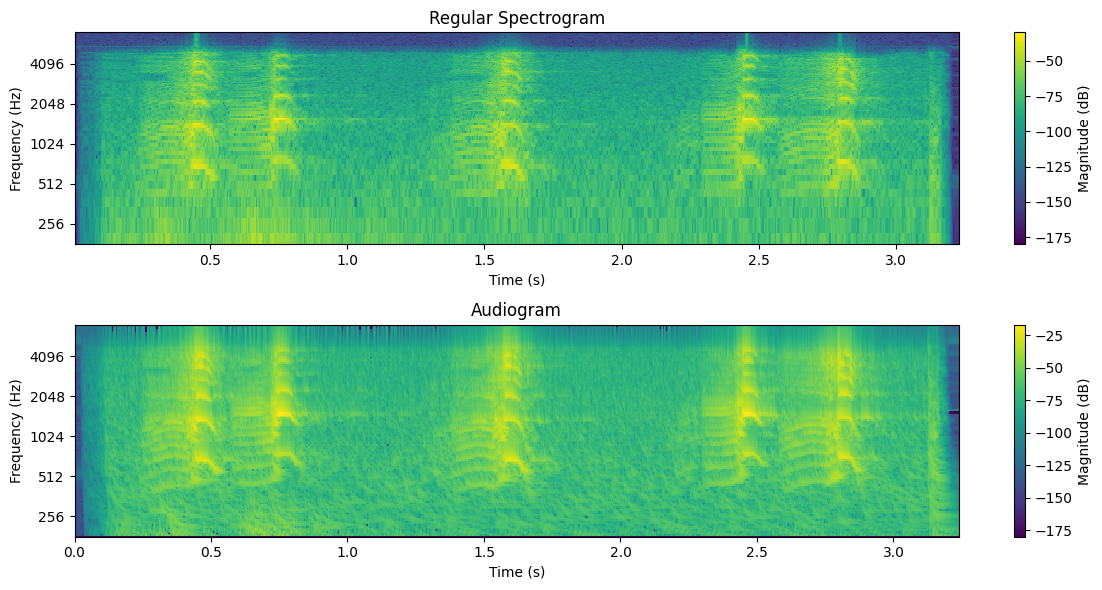

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Convert the magnitude to dB safely
to_decibel = lambda x: 20 * np.log10(np.maximum(x, 1e-9))  # Avoid log of zero by adding a small constant

def plot_matrix(matrix, time_points, frequencies, ylim, title):
    plt.title(title)

    # Use pcolormesh so the linear FFT bins can be mapped to a log scale natively
    plt.pcolormesh(time_points, frequencies, to_decibel(matrix))
    plt.colorbar(label='Magnitude (dB)')

    # Axes labels and scaling
    plt.xlabel("Time (s)")
    plt.yscale('log', base=2)
    plt.ylim(*ylim)  # Limit y-axis to human hearing range
    plt.ylabel("Frequency (Hz)")
    plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.figure(figsize=(12, 6))

# Top plot: regular spectrogram
plt.subplot(2, 1, 1)
plot_matrix(matrix=spectrogram, time_points=time_points_spectrogram, frequencies=frequencies_spectrogram, ylim=[frequencies_audiogram[0], frequencies_audiogram[-1]], title="Regular Spectrogram")

# Bottom plot: audiogram
plt.subplot(2, 1, 2)
plot_matrix(matrix=audiogram, time_points=time_points_audiogram, frequencies=frequencies_audiogram, ylim=[frequencies_audiogram[0], frequencies_audiogram[-1]], title="Audiogram")

plt.tight_layout()
plt.show()

The two audiograms appear very similar at first glance. To illustrate the core differences, we will now plot the frequency distribution of the audiogram and the spectrogram. You will see in the below left plot that the regular spectrogram has a range between 1 and sampling_rate / 2 = 8 kHz, all linearly spaced. By contrast, the audiogram uses a slightly smaller scale of 180-7040 Hz and logarithmic spacing (base 2), due to the specific selection of filters. As a consequence, the audiogram will maintain a stable fractional bandwidth (a measure of resolution) across frequencies while the regular spectrogram uses a relatively larger spacing for the bass and a relatively smaller spacing for the treble sounds. The below right plot illustrates this by approximating the fractional bandwidth per frequency. 

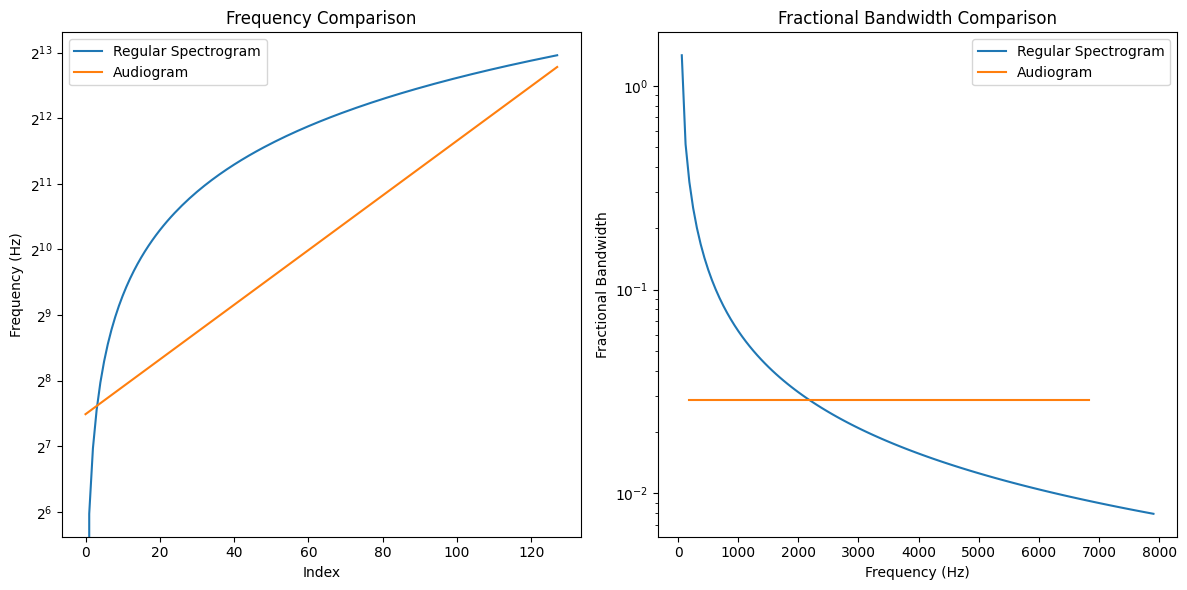

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

# Left plot: frequency bin comparison
plt.subplot(1, 2, 1)
plt.title("Frequency Comparison")
plt.plot(frequencies_spectrogram, label='Regular Spectrogram')
plt.plot(frequencies_audiogram, label='Audiogram')
plt.yscale('log', base=2)
plt.xlabel("Index")
plt.ylabel("Frequency (Hz)")
plt.legend()

# Right plot: resolution comparison
resolution = lambda frequencies: (np.sqrt(frequencies[1:-1] * frequencies[2:]) - np.sqrt(frequencies[1:-1] * frequencies[:-2])) / frequencies[1:-1]  # For each frequency bin, compute the geometric mean w.r.t the neighboring bins as a measure of resolution
plt.subplot(1,2,2); plt.title("Fractional Bandwidth Comparison")
plt.plot(frequencies_spectrogram[1:-1], resolution(frequencies_spectrogram), label='Regular Spectrogram')
plt.plot(frequencies_audiogram[1:-1], resolution(frequencies_audiogram), label='Audiogram')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fractional Bandwidth")
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

## **Step 4: Alternative configurations**
There are numerous ways to configure `wav2aud`, including changing the sampling rate, lateral inhibition parameters or filters. We will go over the most important features next. 

### Adjusting the sampling rate
It is important to note the sampling rate is tightly coupled to the frequency range that the default filters will capture. The function `wav2aud` assumes a default rate of 16 kHz which results in a frequency range of 180-7040 Hz. This corresponds to the musical notes F#3-A8, i.e. ~5.3 octaves. The sampling rate $f_s$ and the octave shift $\Delta o$ relative to the default octaves follow the identity $\Delta o = \log_2(f_s / 16K)$. In `wav2aud`, there are other parameters linked to the octave shift and so, instead of using separate arguments for all of them, `octave_shift` is used as a single parameter. Note that it only supports integers, meaning that you will need your sampling rate to be a power of 2 times 16K. For example, if you have a sampling rate of 

- 8 kHz, set `octave_shift`=-1
- 16 kHz, set `octave_shift`=0
- 32 kHz, set `octave_shift`=1

Here is an example

In [ ]:
# Generate a signal at different sampling rates
note = 1024
octave_shifts = [-1, 0, 1]  # Generate signals at 8 kHz, 16 kHz and 32 kHz
time_points_array = [None] * len(octave_shifts)
frequencies_array = [None] * len(octave_shifts)
audiogram_array = [None] * len(octave_shifts)

# Compute audiograms 
for o, octave_shift in enumerate(octave_shifts):  # Generate signals at 8 kHz, 16 kHz and 32 kHz
    fs_o = (int)(16000 * 2**octave_shift) # Sampling rate
    t_o = np.linspace(0, 1, fs_o) # Input time points
    waveform_o = np.sin(2 * np.pi * note * t_o)  # 1 second of audio 

    # Generate audiograms for each signal
    time_points_array[o], frequencies_array[o], audiogram_array[o]  = wav2aud(waveform_o, octave_shift=octave_shift)

# Plot audiograms for each signal
plt.figure(figsize=(12,4))
for o, octave_shift in enumerate([-1, 0, 1]):
    plt.subplot(1, len(octave_shifts), o + 1)
    fs_o = (int)(16000 * 2**octave_shift)
    plot_matrix(matrix=audiogram_array[o], time_points=time_points_array[o], frequencies=frequencies_array[o], ylim=[frequencies_array[0][0], frequencies_array[-1][-1]],  title=f"Audiogram at {fs_o} Hz")
plt.tight_layout()
plt.show()

### Adjusting the activation function
The `wav2aud` function applies its filters, each tuned to the characteristic frequency of one section of the cochlea, and then passes the results through an activation function. By default, no activation function is applied. We can adjust this by calibrating the `sigmoid_factor` $\sigma$. Here are the values for this parameter and their meaning:

- $\sigma > 0$ results in the use of a transistor-like sigmoid of the form $\frac{1}{1+e^{-x/\sigma}}$, where $\sigma$ corresponds to the inverse slope, i.e. with $\sigma$ close to $0$, it leads to a steep slope, with $\sigma$ being large and positive, it leads to a flat slope.
- $\sigma = 0$ results in the use of a step function centred at zero.
- $\sigma = -1$ results in a rectified linear function of the form $max(0,x)$.
- other: results in the default identity function.

We will compare different values for $\sigma$ in the next illustration using your originally selected sound.

In [ ]:
# Compute audiograms at different sigmoid factors
sigmas = [-2, -1, 0, 1, 10]  # Generate signals at different sigmas

# Plot audiograms for each signal
fig=plt.figure(figsize=(12,4))
for s, sigma in enumerate(sigmas): 
    # Compute audiogram
    time_points_s, frequencies_s, audiogram_s  = wav2aud(waveform, sigmoid_factor=sigma)

    plt.subplot(1, len(sigmas), s + 1); plt.title(f"sigmoid_factor == {sigma}")
    plt.pcolormesh(time_points_s, frequencies_s, to_decibel(audiogram_s))

    plt.xlabel("Time (s)")
    plt.yscale('log', base=2)
    plt.ylim(frequencies_s[0], frequencies_s[-1])  # Limit y-axis to human hearing range
    if s == 0: plt.ylabel("Frequency (Hz)")
    plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.show()

### Adjusting the temporal integration constant

Before the audiogram is returned by `wav2aud`, a temporal integration is applied that accumulates information from adjacent time-frames, effectively reducing the number of time-frames in the output. This can be configured by tuning the `time_constant` $t_c$ in milliseconds.

- $t_c > 0$ results in leaky integration and larger values lead to stronger temporal smoothing of the output. 
- $t_c = 0$, results in simple averaging of the sub-samples within a single output time-frame. 

We will demonstrate the effect using your originally selected sound below.

In [ ]:
# Compute audiograms at different temporal integration constants
time_constants = [0, 1, 10, 100]  # In ms

# Plot audiograms for each signal
fig=plt.figure(figsize=(12,4))
for t, time_constant in enumerate(time_constants): 
    # Compute audiogram
    time_points_t, frequencies_t, audiogram_t  = wav2aud(waveform, time_constant=time_constant)

    plt.subplot(1, len(time_constants), t + 1); plt.title(f"time_constant == {time_constant} ms")
    plt.pcolormesh(time_points_t, frequencies_t, to_decibel(audiogram_t))

    plt.xlabel("Time (s)")
    plt.yscale('log', base=2)
    plt.ylim(frequencies_t[0], frequencies_t[-1])  # Limit y-axis to human hearing range
    if t == 0: plt.ylabel("Frequency (Hz)")
    plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.show()

### Adjusting the filters
The `wav2aud` function comes with a set of 129 default filters, each being tuned to the characteristic frequency of one section of the cochlea. In the cochlea, adjacent sections inhibit each other through a process known as lateral inhibition. The function `wav2aud` imitates this by subtracting the output of the next higher filter from a given filter. Consequently, it needs one more filter than frequency channels found in the output (129 filters for 128 output channels). To provide your custom filters, use the zeros, poles, gain format:

- `zeros` : A numpy.ndarray for transfer function zeros with dimensions (maximum number of zeros, number of filters).
- `poles` : A numpy.ndarray for transfer function poles with dimensions (maximum number of poles, number of filters).
- `gain` : A numpy.ndarray array of length equal to the number of filters. 

For example, for a filter-bank with 3 filters where the first one has 2 zeros, the second has 5 and the third
has 3, the value of 'zeros' in the dictionary should correspond to a (5x3) array. Any slots 
not filled by the zeros of a filter should have NaNs instead. The same applies to the 'poles'
array. The 'gain' array should have length equal to the number of channels (here, 3), and only one dimension. The below code shows such an example with arbitrary numbers.

In [9]:
# Define a system with 3 filters (i.e. columns in the below matrices)
zeros = np.array(
    [[0.5,  -0.1, -0.5 ],
    [0.2,  0.3, -0.4 ],
    [None, -0.9, 0.9 ],
    [None, 0.25, None],
    [None, 0.6, None]], dtype=np.float32)

poles = np.array(
    [[-0.5,  0.15, -0.2 ],
    [0.1,  -0.2, -0.1 ],
    [None, 0.4, 0.8 ],
    [None, 0.5, None],
    [None, -0.2, None]], dtype=np.float32)

gain = np.array([1.0, 0.8, 0.5], dtype=np.float32)

# Compute the audiogram with custom filters
wav2aud(waveform, filters={'zeros': zeros, 'poles' : poles, 'gain': gain});

# References
[1] Yang, X., Wang, K., and Shamma, S. A. (1992). "Auditory
       representations of acoustic signals." *IEEE Transactions on
       Information Theory*, 38(2), 824-839.
       https://doi.org/10.1109/18.119739

[2] Wang, K., and Shamma, S. A. (1994). "Self-normalization and
       noise-robustness in early auditory representations." *IEEE
       Transactions on Speech and Audio Processing*, 2(3), 421-435.
       https://doi.org/10.1109/89.294356